# **Modelo mensual de predicción de new_churn_t+1**

## Importaciones y diccionario de variables

In [195]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, confusion_matrix, classification_report, precision_recall_curve, recall_score
import matplotlib.pyplot as plt

In [196]:
monthly_master = pd.read_csv('data/processed/monthly_master.csv')

monthly_master.columns

Index(['store_id', 'period_month', 'tpn', 'gmv', 'days_with_orders',
       'markdown_mean', 'avg_shipping_cost', 'si_ios_prop', 'si_meli_prop',
       'si_other_prop', 'free_shipping_prop', 'w_tpn_w1', 'w_tpn_w2',
       'w_tpn_w3', 'w_tpn_w4', 'w_tpn_w5', 'w_gmv_w1', 'w_gmv_w2', 'w_gmv_w3',
       'w_gmv_w4', 'w_gmv_w5', 'w_tpn_w6', 'w_gmv_w6', 'churn', 'churn_streak',
       'churn_2m_consec', 'churn_4m_consec_or_more', 'churn_unique', 'stage',
       'created_date', 'segmento', 'comision_actual', 'in-house_delivery',
       'store_type', 'barrio', 'category', 'cooking_time', 'tiene_otra_app',
       'brand_id', 'ciudad', 'total_min_open', 'total_min_paused',
       'total_min_closed', 'total_minutes_all'],
      dtype='object')

### Diccionario de variables (monthly_master)

| Variable | Tipo | Descripción |
|---|---|---|
| `store_id` | int/str | Identificador único de la tienda. |
| `period_month` | str (YYYY-MM) | Mes de referencia del registro. |
| `tpn` | int | Pedidos/ventas netas del mes (Total Pedidos Netos). |
| `gmv` | float | Gross Merchandise Value del mes (monto total vendido). |
| `days_with_orders` | int | Días del mes con al menos un pedido. |
| `markdown_mean` | float | Descuento/promoción promedio aplicado en el mes (0–1). |
| `avg_shipping_cost` | float | Costo de envío promedio por pedido en el mes. |
| `si_ios_prop` | float | Proporción de pedidos por canal iOS (0–1). |
| `si_meli_prop` | float | Proporción de pedidos por canal MELI/web (0–1). |
| `si_other_prop` | float | Proporción de pedidos por otros canales (0–1). |
| `free_shipping_prop` | float | Proporción de pedidos con envío gratis (0–1). |
| `churn` | {0,1} | Flag de churn en el mes (1 = churn). |
| `churn_streak` | int | Cantidad de meses consecutivos en churn hasta el mes actual. |
| `churn_2m_consec` | {0,1} | 1 si acumula ≥2 meses consecutivos en churn. |
| `churn_4m_consec_or_more` | {0,1} | 1 si acumula ≥4 meses consecutivos en churn. |
| `churn_unique` | {0,1} | 1 si el churn de este mes es el **primer** churn del streak. |
| `stage` | str | Etapa de la tienda (p.ej., `Activo`, `Inactivo`, `New`). |
| `created_date` | date | Fecha de creación de la tienda. |
| `segmento` | str | Segmento comercial asignado a la tienda. |
| `comision_actual` | float | % de comisión vigente (0–1 o 0–100 según fuente). |
| `in-house_delivery` | {0,1} | 1 si la tienda utiliza logística propia. |
| `store_type` | str | Tipo de tienda (cadena, independiente, etc.). |
| `barrio` | str | Barrio de la tienda. |
| `category` | str | Categoría principal (cocina/rubro). |
| `cooking_time` | float/int | Tiempo de preparación estimado (minutos). |
| `tiene_otra_app` | {0,1} | 1 si opera en otras apps/plataformas. |
| `brand_id` | str/int | Identificador de la marca/cadena (si corresponde). |
| `total_min_open` | float/int | Minutos con estado **OPEN** en el mes. |
| `total_min_paused` | float/int | Minutos con estado **PAUSED** en el mes. |
| `total_min_closed` | float/int | Minutos con estado **CLOSED** en el mes. |
| `total_minutes_all` | float/int | Suma de minutos Open+Paused+Closed en el mes. |

## Data engineering
- Filtrar datos: mantener solo CABA y eliminar datos de septiembre 2025 (09-2025)
- Nuevas features:
    - Lag (-1): tpn, gmv
    - Lag (-2): tpn, gmv
    - MoM (%): tpn, gmv
    - Antigüedad de la store (en meses)
    - Variable de fecha pasan a ser ciclicas
- Encoding de categoricas
    - category (freq encoder)
    - barrio (freq encoder)
    - segmento (one-hot)
- Drop de columnas innecesarias

In [197]:
monthly_master_new = monthly_master.copy()

Filtrar datos: mantener solo CABA y eliminar datos de septiembre 2025 (09-2025)

In [198]:
# Filtrar solo datos de CABA
monthly_master_new = monthly_master_new[monthly_master_new['ciudad'] == 'CABA']

# Convertir las columnas de fecha a tipo datetime
monthly_master_new["created_date"] = pd.to_datetime(monthly_master_new["created_date"])
monthly_master_new["period_date"] = pd.to_datetime(monthly_master_new["period_month"], format="%Y-%m")

monthly_master_new = monthly_master_new.sort_values(["store_id","period_date"]).reset_index(drop=True)

# Quedarse solo con datos hasta agosto 2025 (ya que septiembre 2025 está incompleto)
monthly_master_new = monthly_master_new[monthly_master_new['period_date'] < '2025-09-01']

monthly_master_new.rename(columns={'churn_unique': 'new_churn'}, inplace=True)

### Definición de población elegible y preparación del set de modelado

**Objetivo.** Predecir, a partir de información del mes completo _t_, la probabilidad de que una tienda entre en *churn* (primer mes de churn: `churn_unique = 1`) el mes siguiente osea _t+1_, usando solo información disponible hasta _t_.

**Problema detectado.** En la base existen filas “pre-alta real” (meses anteriores a el primer mes con ventas) donde `churn_unique` es `NaN`. Es correcto que existan para la grilla mensual, pero **no deben participar** ni en el entrenamiento ni en la evaluación, porque la tienda **aún no era elegible** en esos meses.

Creamos la variable target (churn_t+1)

In [199]:
# Crear variable target (new_churn_t+1)
monthly_master_new["new_churn_t+1"] = monthly_master_new.groupby("store_id")["new_churn"].shift(-1)

Feature: tasa de conectividad

In [200]:
# Calcular conectividad por fila
monthly_master_new['connectivity'] = np.where(monthly_master_new['total_minutes_all'] > 0, monthly_master_new['total_min_open'] / monthly_master_new['total_minutes_all'], np.nan)
monthly_master_new['connectivity'] = monthly_master_new['connectivity'].clip(0, 1)

Nuevas features temporales:
- Lag (-1): tpn, gmv, connectivity, days_with_orders, markdown_mean, avg_shipping_cost, free_shipping_prop, total_min_open, total_minutes_all
- Lag (-2): tpn, gmv, connectivity, days_with_orders, markdown_mean, avg_shipping_cost, free_shipping_prop, total_min_open, total_minutes_all
- MoM (%): tpn, gmv, connectivity
- Antigüedad de la store (en meses)
- Variable de fecha pasan a ser ciclicas

In [149]:
# Nuevas variables temporales (lag)

# --- Lag features,  Mom%, rolling average, deviation and standard deviation from rolling average ---
for col in ["tpn","gmv","connectivity","days_with_orders","markdown_mean","avg_shipping_cost","free_shipping_prop","total_min_open","total_minutes_all"]:
    # lag t-1 and t-2
    monthly_master_new[f"{col}_t-1"] = monthly_master_new.groupby("store_id")[col].shift(1)
    monthly_master_new[f"{col}_t-2"] = monthly_master_new.groupby("store_id")[col].shift(2)
    
    # month-over-month % vs previous month
    monthly_master_new[f"{col}_mom_pct"] = (monthly_master_new[col] - monthly_master_new[f"{col}_t-1"]) / monthly_master_new[f"{col}_t-1"]
    # handle divisions by zero / inf
    monthly_master_new.loc[ monthly_master_new[f"{col}_t-1"] == 0, f"{col}_mom_pct"] = np.nan
    monthly_master_new.loc[ np.isinf(monthly_master_new[f"{col}_mom_pct"]), f"{col}_mom_pct"] = np.nan

    # 1. Cálculo de la Media Móvil (Rolling Mean) 3 meses
    # Se aplica el rolling directamente sobre el grupo, incluyendo el valor del mes actual (t)
    monthly_master_new[f"{col}_rolling_avg_3m"] = (
        monthly_master_new
        .groupby("store_id")[col]
        .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    )
    
    # 2. Cálculo de la Desviación del Valor Actual vs. la Media Móvil
    monthly_master_new[f"{col}_dev_from_rolling_avg_3m"] = (
        monthly_master_new[col] - monthly_master_new[f"{col}_rolling_avg_3m"]
    )
    
    # 3. Desviación ESTÁNDAR (Volatilidad)  <-- ESTA ES LA NUEVA FEATURE
    monthly_master_new[f"{col}_rolling_std_3m"] = (
        monthly_master_new.groupby("store_id")[col]
        .transform(lambda x: x.rolling(window=3, min_periods=1).std())
    )

In [201]:
# Variables tipo fecha a ciclicas 

    # period-month (variables ciclicas)

        # period_month (1..12)
monthly_master_new["period_month"] = monthly_master_new["period_date"].dt.month
monthly_master_new["period_month_sin"] = np.sin(2 * np.pi * monthly_master_new["period_month"] / 12)
monthly_master_new["period_month_cos"] = np.cos(2 * np.pi * monthly_master_new["period_month"] / 12)

        # period_year (no es ciclica)
monthly_master_new["period_year"] = monthly_master_new["period_date"].dt.year

    # created_date (variables ciclicas)

        # created_month (1..12)
monthly_master_new["created_month"] = monthly_master_new["created_date"].dt.month
monthly_master_new["created_month_sin"] = np.sin(2 * np.pi * monthly_master_new["created_month"] / 12)
monthly_master_new["created_month_cos"] = np.cos(2 * np.pi * monthly_master_new["created_month"] / 12)

        # created_year (no es ciclica)
monthly_master_new["created_year"] = monthly_master_new["created_date"].dt.year

        # created_day (1..30)
monthly_master_new["created_day"] = monthly_master_new["created_date"].dt.day
monthly_master_new["created_day_sin"] = np.sin(2 * np.pi * (monthly_master_new["created_day"] - 1) / 30) 
monthly_master_new["created_day_cos"] = np.cos(2 * np.pi * (monthly_master_new["created_day"] - 1) / 30)

In [202]:
# Antigüedad en meses de la store en cada mes (period_date - created_date)
monthly_master_new["antiguedad_meses"] = ((monthly_master_new["period_date"].dt.year - monthly_master_new["created_date"].dt.year) * 12 + (monthly_master_new["period_date"].dt.month - monthly_master_new["created_date"].dt.month)).clip(lower=0).astype(int)

Encoding de variables categoricas

In [203]:
cat_cols = ['segmento', 'barrio', 'category']
for c in cat_cols:
    if c in monthly_master_new.columns:
        monthly_master_new[c] = monthly_master_new[c].astype('category')

In [ ]:
# Eliminar columnas innecesarias
monthly_master_new = monthly_master_new.drop(columns=['period_month', 'stage', 'created_date', 'ciudad', 'store_type', 'si_ios_prop', 'si_meli_prop', 'si_other_prop'])

In [205]:
monthly_master_new.head()

,store_id,tpn,gmv,days_with_orders,markdown_mean,avg_shipping_cost,si_ios_prop,si_meli_prop,si_other_prop,free_shipping_prop,...,period_month_cos,period_year,created_month,created_month_sin,created_month_cos,created_year,created_day,created_day_sin,created_day_cos,antiguedad_meses
0,100006,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,-8.660254e-01,2024,7,-0.5,-0.866025,2024,15,0.207912,-0.978148,0
1,100006,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,-5.000000e-01,2024,7,-0.5,-0.866025,2024,15,0.207912,-0.978148,1
2,100006,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.836970e-16,2024,7,-0.5,-0.866025,2024,15,0.207912,-0.978148,2
3,100006,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,5.000000e-01,2024,7,-0.5,-0.866025,2024,15,0.207912,-0.978148,3
4,100006,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,8.660254e-01,2024,7,-0.5,-0.866025,2024,15,0.207912,-0.978148,4


## Entrenamiento del modelo

### División train y test

In [206]:
# --------------------------
# CONFIG (ajustá según tu caso)
# --------------------------

TARGET_COL = 'new_churn_t+1'          # target 0/1

# Columnas categóricas a frequency-encode (si no las tenés ya encoded)
# FREQ_ENC_COLS = ['barrio','category']  # si ya hiciste barrio_freq/category_freq podés dejar vacío

# Ajustá TEST_YEAR_MONTH (formato 'YYYY-MM') al agosto que querés usar como test.
TEST_YEAR_MONTH = '2025-07'  # test en julio 2025 (predecir churn_t+1 osea agosto 2025)
TEST_PERIOD = pd.to_datetime(TEST_YEAR_MONTH + '-01')

In [207]:
# filas con target NaN no se usan para entrenamiento, pero pueden incluirse en producción
df_trainable = monthly_master_new[~monthly_master_new[TARGET_COL].isna()].copy().reset_index(drop=True)

In [208]:
# Construir test set: filas cuyo period_date == TEST_PERIOD
test_idx = df_trainable[df_trainable['period_date'] == TEST_PERIOD].index

# Considerar todas las demás filas como train (train )
train_idx = df_trainable.index.difference(test_idx)

In [209]:
# split X/y
X = df_trainable.drop(columns=[TARGET_COL]).copy()
y = df_trainable[TARGET_COL].astype(int).copy()

X_test = X.loc[test_idx].copy()
X_test = X_test.drop(columns=['period_date'])
y_test = y.loc[test_idx].copy()

X_train = X.loc[train_idx].copy()
X_train = X_train.drop(columns=['period_date'])
y_train = y.loc[train_idx].copy()

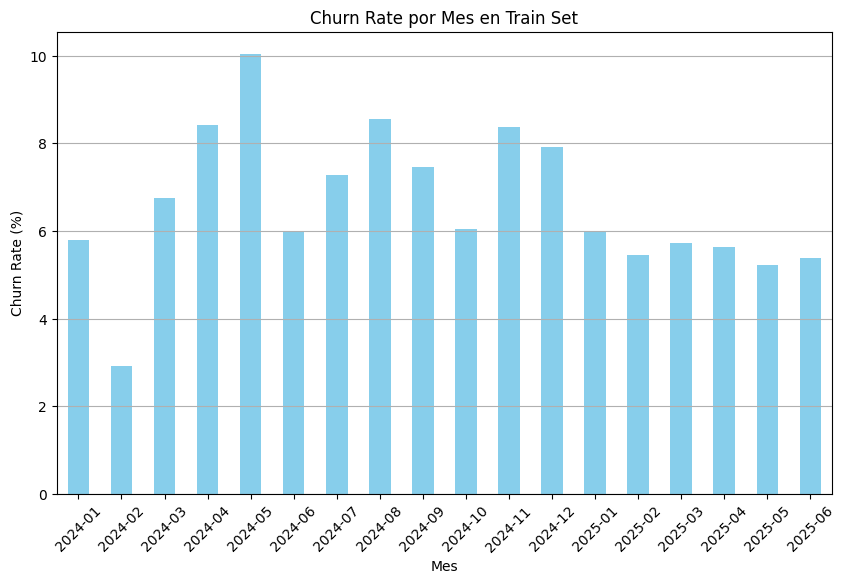

In [210]:
# Grafico de desbalanceo de variable target en train por mes (en porcentaje sobre total de stores en ese mes)
train_df = df_trainable.loc[train_idx].copy()
train_df['period_month'] = train_df['period_date'].dt.to_period('M')
churn_rate_by_month = train_df.groupby('period_month')[TARGET_COL].mean()*100
churn_rate_by_month.plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Churn Rate por Mes en Train Set')
plt.xlabel('Mes')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [211]:
y_train.value_counts(normalize=True)

new_churn_t+1
0    0.936813
1    0.063187
Name: proportion, dtype: float64

El desbalanceo moderado (1-5%) pero no extremo (<1%) mes a mes. Se va a utilizar el argumento de ponderacion de lightgbm para clase positiva minoritaria

### Entrenamiento del modelo

In [212]:
# parámetros LightGBM (baseline)
NUM_BOOST_ROUND = 200
N_JOBS = -1

LGB_PARAMS = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'seed': 42,
    'verbosity': -1,
    'n_jobs': N_JOBS,
    'is_unbalance': True
}

In [213]:
# -------- Entrenar LightGBM --------
dtrain = lgb.Dataset(X_train, label=y_train)
bst = lgb.train(LGB_PARAMS, dtrain, num_boost_round=NUM_BOOST_ROUND)

# -------- Predicción en test (probabilidades) --------
y_test_pred_proba = bst.predict(X_test, num_iteration=bst.best_iteration or NUM_BOOST_ROUND)

In [214]:
# -------- Métricas (probabilísticas / ranking) --------
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba) if len(np.unique(y_test)) > 1 else np.nan
test_pr_auc = average_precision_score(y_test, y_test_pred_proba) if len(np.unique(y_test)) > 1 else np.nan
test_brier = brier_score_loss(y_test, y_test_pred_proba)

print("Métricas probabilísticas (test):")
print(f"  ROC AUC: {test_roc_auc:.4f}")
print(f"  PR-AUC (Average Precision): {test_pr_auc:.4f}")
print(f"  Brier score: {test_brier:.4f}")
print()

Métricas probabilísticas (test):
  ROC AUC: 0.9272
  PR-AUC (Average Precision): 0.3924
  Brier score: 0.0585



In [215]:
# ---------- 1) confusion matrix y classification report a threshold fijo ----------
TH = 0.5
y_pred_label = (y_test_pred_proba >= TH).astype(int)

print("Matriz de confusión:")
labels = ['Retained', 'Churned']
pd.DataFrame(confusion_matrix(y_test, y_pred_label), index=[f"True_{l}" for l in labels], columns=[f"Pred_{l}" for l in labels])

Matriz de confusión:


,Pred_Retained,Pred_Churned
True_Retained,3226,249
True_Churned,59,123


In [216]:
print("Matriz de confusión (proporción de los reales):")
pd.DataFrame(confusion_matrix(y_test, y_pred_label, normalize='true'), index=[f"True_{l}" for l in labels], columns=[f"Pred_{l}" for l in labels])

Matriz de confusión (proporción de los reales):


,Pred_Retained,Pred_Churned
True_Retained,0.928345,0.071655
True_Churned,0.324176,0.675824


Dado que el objetivo prioritario es identificar correctamente a las tiendas con riesgo de abandono, se decide emplear como métrica central el Recall, ya que mide la proporción de verdaderos churners detectados sobre el total de churners reales.

Una mayor cantidad de falsos negativos (siendo la clase positiva = churned), indicarian que no se llegó a anticipar el churneo de las stores correctamente.
En cambio, los falsos positivos (osea predecir que va a caer el churn cuando no lo hace realmente) no es tan costoso ya que nosotros no cuantificamos el costo de intervenir una store. Mientras que, los posibles ingresos de MercadoDelivery de intervenir una store a tiempo, si se cuantifica. Por lo tanto, buscamos reducir estos falsos negativos.

In [217]:
print("Classification report (threshold = {:.2f}):".format(TH))
print(classification_report(y_test, y_pred_label, digits=4, zero_division=0))

Classification report (threshold = 0.50):
              precision    recall  f1-score   support

           0     0.9820    0.9283    0.9544      3475
           1     0.3306    0.6758    0.4440       182

    accuracy                         0.9158      3657
   macro avg     0.6563    0.8021    0.6992      3657
weighted avg     0.9496    0.9158    0.9290      3657



Observando el recall (de la clase positiva), se puede ver que un 59% de las stores que realmente iban a entrar en churn, fueron predichas correctamente que iban a entrar en churn. A pesar de ser alta la métrica, hay un ~41% de stores que van a churnear en agosto que fueron incorrectamente clasificados como que iban a tener actividad. Esto es de interes ya que implica una perdida de posibles ingresos al no intervenir en esas stores a tiempo.

En cuanto a la precision, un 31% de los que se predijo que iban a caer en churn en agosto, realmente cayeron en churn.

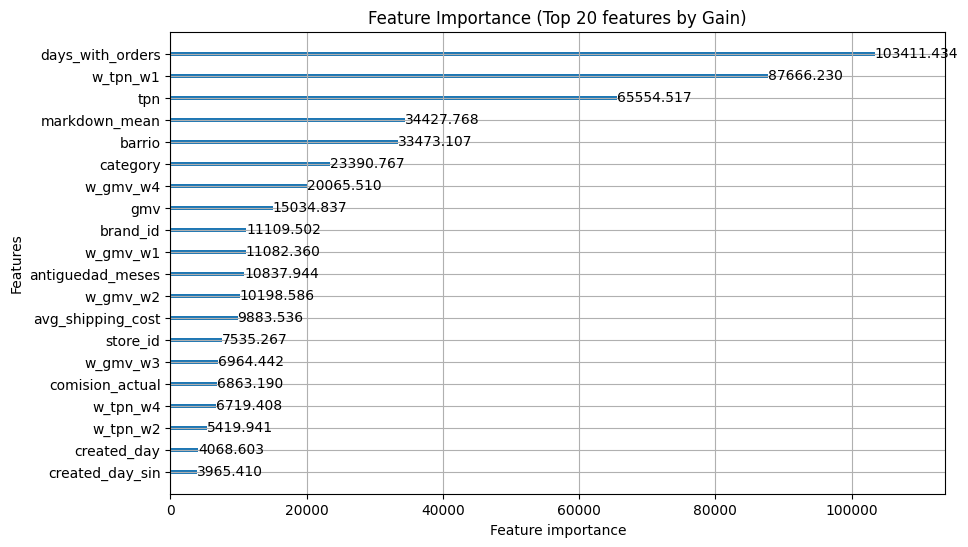

In [191]:
# Ver feature importance del modelo
lgb.plot_importance(bst, max_num_features=20, importance_type='gain', figsize=(10,6))
plt.title('Feature Importance (Top 20 features by Gain)')
plt.show()

In [122]:
import shap

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [192]:
# 1. Inicializar el Explainer para modelos basados en árboles
explainer = shap.TreeExplainer(bst)

# 2. Calcular los valores SHAP
# Esto es la contribución de cada feature a cada predicción en el set de muestra
shap_values = explainer.shap_values(X_train)

# Si es clasificación binaria, verifica si es una lista y usa el índice 1 para la Clase Positiva/Churn
if isinstance(shap_values, list):
    # Seleccionas los SHAP values para la clase 1 (Churn)
    shap_values = shap_values[1] 

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


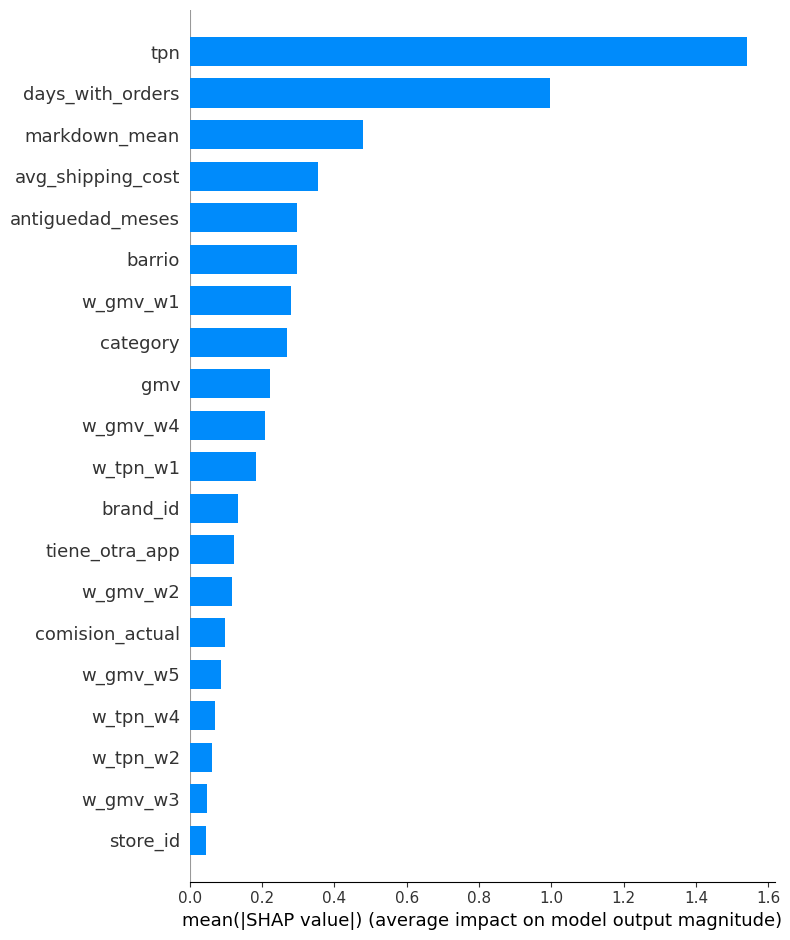

In [193]:
# Grafica el impacto promedio absoluto de cada feature
# Este es el análisis más rápido y directo de la importancia global
shap.summary_plot(
    shap_values, 
    X_train, 
    plot_type="bar", 
    max_display=20 # Muestra solo las 20 features más importantes
)

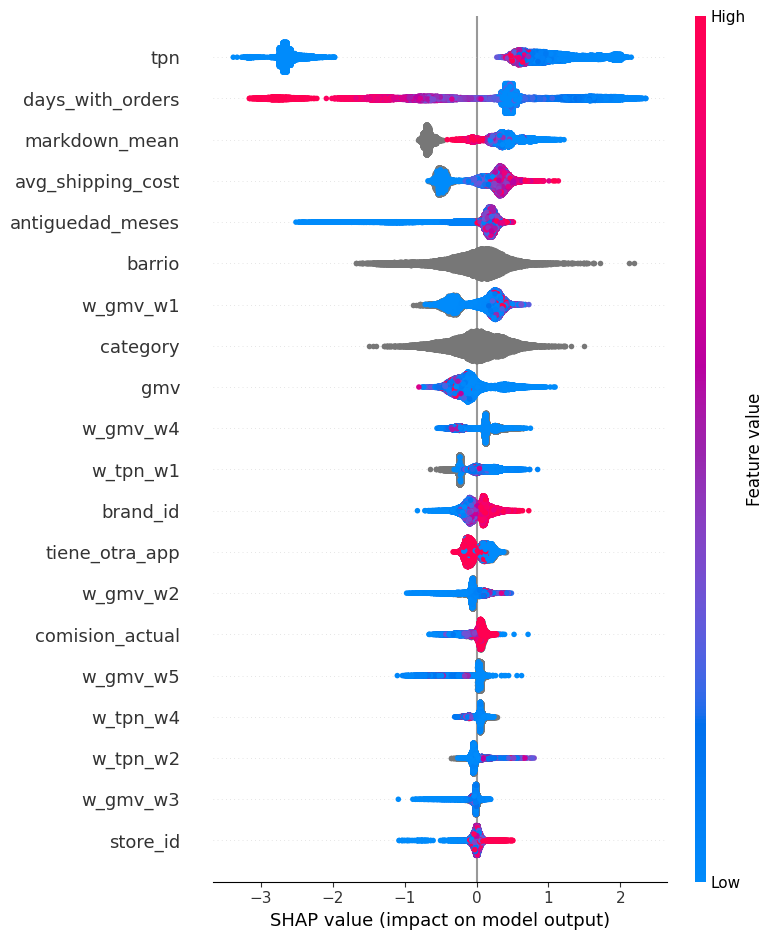

In [194]:
# Grafica la importancia de cada feature y cómo su valor (color) afecta la predicción
shap.summary_plot(
    shap_values, 
    X_train, 
    max_display=20
)

In [136]:
X_train['si_other_prop'].unique()

array([       nan, 0.        , 0.015625  , 0.01612903, 0.07142857,
       0.01492537, 0.01538462, 0.02325581, 0.02702703, 0.01785714,
       0.01515152, 0.03703704, 1.        , 0.01754386, 0.11111111,
       0.01470588, 0.04      , 0.01265823, 0.02      , 0.01351351,
       0.01315789, 0.01639344, 0.14285714])